# Assignment 2: End-to-End Machine Learning Pipeline

## Business Account Upgrade Prediction Using Logistic Regression

**Course:** MBAI 5310G – AI Programming
**Model:** Logistic Regression Baseline Model
**Dataset:** `business_account_upgrade_prediction_dataset.csv`

## Step 1: Introduction and Assignment Objective

This notebook develops a basic end-to-end machine learning pipeline for a business account upgrade prediction problem. The purpose of the model is to predict whether a business account is likely to upgrade its account based on available account characteristics, business activity, product usage, revenue information, support history, and sales-related indicators.

The assignment focuses on building a complete machine learning workflow rather than only training a model. Therefore, this notebook follows the main stages of an applied machine learning pipeline: understanding the business problem, loading and inspecting the dataset, identifying the target variable and input features, cleaning the data, handling missing values, separating features and target, splitting the data into training and testing sets, applying preprocessing, training a Logistic Regression baseline model, and evaluating the model results.

The goal is to show how raw business data can be converted into a structured machine learning process that supports prediction and business decision-making.

## Step 2: Business Problem and Dataset Overview

Many businesses offer different account plans or service levels to their customers. Some business accounts may remain on their current plan, while others may upgrade to a higher-value account. Understanding which accounts are more likely to upgrade can help a company improve sales planning, customer relationship management, training support, and targeted marketing strategies.

The main business problem is to identify business accounts that have a higher likelihood of upgrading. Some accounts may show stronger upgrade potential through higher annual revenue, more frequent monthly transactions, greater product usage, longer account history, training attendance, previous sales contact, or other engagement-related behaviours.

The business question is:

**Can the company predict whether a business account will upgrade using account information, revenue details, transaction activity, product usage, support history, sales contact information, and customer engagement indicators?**

The dataset used in this project is `business_account_upgrade_prediction_dataset.csv`. Each row represents one business account. The dataset includes variables such as company size, industry, annual revenue, monthly transactions, current plan, account age, support tickets, sales contact status, product usage score, monthly fee, training attendance, and upgrade behaviour.

The target variable is `Upgraded_Account`, which shows whether the account upgraded or did not upgrade. Since the target variable has two possible values, **Yes** and **No**, this is a supervised binary classification problem.

A machine learning model can help the business identify accounts that may be more suitable for follow-up by the sales or customer success team. For example, accounts predicted as likely to upgrade may be prioritized for sales contact, product demonstrations, training support, account reviews, or upgrade offers.

For this assignment, Logistic Regression is used as a baseline model because it is a simple and commonly used classification method for predicting binary outcomes. The purpose is to build a clear first version of the machine learning pipeline before considering more advanced models.



## Step 3: Importing Libraries and Loading the Dataset

In this step, the required Python libraries are imported and the business account upgrade prediction dataset is loaded into Python.

The imported libraries support the main parts of the machine learning pipeline. `pandas` is used for data loading and data handling. `matplotlib` is used for creating simple visualizations. Scikit-learn tools are used for train-test splitting, preprocessing, model training, and model evaluation.

The dataset file used in this notebook is named `business_account_upgrade_prediction_dataset.csv`. The file should be saved in the same folder as this notebook so that it can be loaded correctly using `pd.read_csv()`.

After loading the file, the dataset is stored in a pandas DataFrame named `df`. This allows us to examine the rows, columns, data types, missing values, duplicate records, and target variable distribution before building the machine learning model.

Loading the dataset is the first practical step in the machine learning pipeline because the model cannot be developed until the data is available in a structured format.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Display all columns when viewing the dataset
pd.set_option("display.max_columns", None)

# Print a confirmation message
print("Libraries imported successfully!")

# Load the dataset
file_path = "C:/Users/praba/OneDrive/Desktop/Assignment_2_GitHub_Submission/business_account_upgrade_prediction_dataset.xls"
df = pd.read_csv(file_path)

print("Dataset loaded successfully!")
print("Dataset shape:", df.shape)

df.head()

Libraries imported successfully!
Dataset loaded successfully!
Dataset shape: (377, 13)


,Account_ID,Company_Size,Industry,Annual_Revenue,Monthly_Transactions,Current_Plan,Account_Age_Months,Support_Tickets,Sales_Contacted,Product_Usage_Score,Monthly_Fee,Training_Attended,Upgraded_Account
0,1,Small,Healthcare,4765975.0,368,Business,26,5,No,55.0,2832,Yes,No
1,2,Small,Manufacturing,5683548.0,257,Basic,75,4,No,5.0,1215,Yes,No
2,3,Enterprise,Manufacturing,1722517.0,424,Premium,99,0,No,64.0,753,No,No
3,4,Enterprise,Education,3481277.0,190,Standard,33,0,Yes,86.0,1973,No,Yes
4,5,Small,Finance,1023375.0,262,Basic,52,3,No,88.0,3676,Yes,No


## Step 4: Initial Data Inspection

After loading the dataset, the next step is to inspect its structure and quality. This includes checking the number of rows and columns, viewing the first few records, reviewing column names, checking data types, identifying missing values, checking duplicate rows, and examining the distribution of the target variable.

This step is important because machine learning models depend on the quality and structure of the data. If the dataset contains missing values, duplicated records, incorrect data types, or unclear target values, these issues should be identified before model training.

Initial inspection also helps confirm which columns can be used as input features and which column should be used as the prediction target.

In [2]:
# Print a title for this output
print("Dataset Shape")

# Print a separator line to make the output clear
print("-" * 50)

# Show the number of rows and columns in the dataset
print(df.shape)

Dataset Shape
--------------------------------------------------
(377, 13)


In [3]:
# Print a title for this output
print("First Five Rows of the Dataset")

# Print a separator line to make the output clear
print("-" * 50)

# Display the first five rows of the dataset
display(df.head())

First Five Rows of the Dataset
--------------------------------------------------


,Account_ID,Company_Size,Industry,Annual_Revenue,Monthly_Transactions,Current_Plan,Account_Age_Months,Support_Tickets,Sales_Contacted,Product_Usage_Score,Monthly_Fee,Training_Attended,Upgraded_Account
0,1,Small,Healthcare,4765975.0,368,Business,26,5,No,55.0,2832,Yes,No
1,2,Small,Manufacturing,5683548.0,257,Basic,75,4,No,5.0,1215,Yes,No
2,3,Enterprise,Manufacturing,1722517.0,424,Premium,99,0,No,64.0,753,No,No
3,4,Enterprise,Education,3481277.0,190,Standard,33,0,Yes,86.0,1973,No,Yes
4,5,Small,Finance,1023375.0,262,Basic,52,3,No,88.0,3676,Yes,No


In [4]:
# Print a title for this output
print("Last Five Rows of the Dataset")

# Print a separator line to make the output clear
print("-" * 50)

# Display the last five rows of the dataset
display(df.tail())

Last Five Rows of the Dataset
--------------------------------------------------


,Account_ID,Company_Size,Industry,Annual_Revenue,Monthly_Transactions,Current_Plan,Account_Age_Months,Support_Tickets,Sales_Contacted,Product_Usage_Score,Monthly_Fee,Training_Attended,Upgraded_Account
372,314,Large,Education,4054009.0,125,Basic,99,6,No,56.0,3005,No,No
373,261,Small,Finance,5943853.0,190,Business,116,10,Yes,58.0,172,No,No
374,272,Small,Technology,6513840.0,301,Standard,92,9,Yes,69.0,983,Yes,Yes
375,222,Enterprise,Technology,2754584.0,409,Standard,85,5,Yes,95.0,504,No,Yes
376,49,Small,Technology,7512369.0,176,Basic,101,4,Yes,55.0,279,No,No


In [5]:
# Print a title for this output
print("Column Names")

# Print a separator line to make the output clear
print("-" * 50)

# Display all column names as a list
print(df.columns.tolist())

Column Names
--------------------------------------------------
['Account_ID', 'Company_Size', 'Industry', 'Annual_Revenue', 'Monthly_Transactions', 'Current_Plan', 'Account_Age_Months', 'Support_Tickets', 'Sales_Contacted', 'Product_Usage_Score', 'Monthly_Fee', 'Training_Attended', 'Upgraded_Account']


In [6]:
# Print a title for this output
print("Dataset Information")

# Print a separator line to make the output clear
print("-" * 50)

# Show general information about the dataset
# This includes column names, non-null counts, and data types
df.info()

Dataset Information
--------------------------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 377 entries, 0 to 376
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Account_ID            377 non-null    int64  
 1   Company_Size          370 non-null    str    
 2   Industry              370 non-null    str    
 3   Annual_Revenue        370 non-null    float64
 4   Monthly_Transactions  377 non-null    int64  
 5   Current_Plan          370 non-null    str    
 6   Account_Age_Months    377 non-null    int64  
 7   Support_Tickets       377 non-null    int64  
 8   Sales_Contacted       370 non-null    str    
 9   Product_Usage_Score   370 non-null    float64
 10  Monthly_Fee           377 non-null    int64  
 11  Training_Attended     377 non-null    str    
 12  Upgraded_Account      377 non-null    str    
dtypes: float64(2), int64(5), str(6)
memory usage: 38.4 KB


In [7]:
# Print a title for this output
print("Data Types of Each Column")

# Print a separator line to make the output clear
print("-" * 50)

# Display the data type of each column
display(df.dtypes)

Data Types of Each Column
--------------------------------------------------


Account_ID                int64
Company_Size                str
Industry                    str
Annual_Revenue          float64
Monthly_Transactions      int64
Current_Plan                str
Account_Age_Months        int64
Support_Tickets           int64
Sales_Contacted             str
Product_Usage_Score     float64
Monthly_Fee               int64
Training_Attended           str
Upgraded_Account            str
dtype: object

In [8]:
# Print a title for this output
print("Missing Values in Each Column")

# Print a separator line to make the output clear
print("-" * 50)

# Count missing values in each column
missing_values = df.isnull().sum()

# Display the number of missing values for each column
display(missing_values)

Missing Values in Each Column
--------------------------------------------------


Account_ID              0
Company_Size            7
Industry                7
Annual_Revenue          7
Monthly_Transactions    0
Current_Plan            7
Account_Age_Months      0
Support_Tickets         0
Sales_Contacted         7
Product_Usage_Score     7
Monthly_Fee             0
Training_Attended       0
Upgraded_Account        0
dtype: int64

In [9]:
# Print a title for this output
print("Number of Duplicate Rows")

# Print a separator line to make the output clear
print("-" * 50)

# Count the number of duplicate rows in the dataset
duplicate_rows = df.duplicated().sum()

# Display the number of duplicate rows
print(duplicate_rows)

Number of Duplicate Rows
--------------------------------------------------
7


In [10]:
# Print a title for this output
print("Summary Statistics for Numerical Columns")

# Print a separator line to make the output clear
print("-" * 50)

# Display summary statistics for numerical columns
display(df.describe())

Summary Statistics for Numerical Columns
--------------------------------------------------


,Account_ID,Annual_Revenue,Monthly_Transactions,Account_Age_Months,Support_Tickets,Product_Usage_Score,Monthly_Fee
count,377.000000,3.700000e+02,377.000000,377.000000,377.000000,370.000000,377.000000
mean,186.265252,4.060962e+06,248.880637,60.962865,6.933687,51.102703,2408.000000
std,106.726653,2.315737e+06,140.723205,35.513763,4.266190,28.988835,1430.944912
min,1.000000,8.265600e+04,0.000000,1.000000,0.000000,0.000000,83.000000
25%,94.000000,1.902595e+06,130.000000,30.000000,4.000000,27.000000,1231.000000
50%,187.000000,4.182715e+06,248.000000,62.000000,7.000000,51.500000,2414.000000
75%,278.000000,6.017136e+06,363.000000,93.000000,10.000000,76.000000,3623.000000
max,370.000000,7.987036e+06,499.000000,119.000000,14.000000,100.000000,4999.000000


In [55]:
# Print a title for this output
print("Summary Statistics for Categorical Columns")

# Print a separator line
print("-" * 50)

# Select categorical/text columns safely
categorical_columns = df.select_dtypes(include=["object", "string"]).columns

# Display summary statistics for categorical/text columns
display(df[categorical_columns].describe())

Summary Statistics for Categorical Columns
--------------------------------------------------


,Company_Size,Industry,Current_Plan,Sales_Contacted,Training_Attended,Upgraded_Account
count,370,370,370,370,377,377
unique,4,6,4,2,2,2
top,Small,Technology,Basic,No,No,No
freq,158,74,132,200,200,293


## Step 5: Understanding the Target Variable and Input Features

In this step, the target variable and input features are identified. This is an important part of the machine learning pipeline because the model must clearly know what it is using to make predictions and what it is trying to predict.

The target variable in this project is `Upgraded_Account`. This column shows whether a business account upgraded its account or not.

The possible values of the target variable are:

* **Yes:** the business account upgraded.
* **No:** the business account did not upgrade.

Because the target variable has two possible categories, this is a supervised binary classification problem.

The input features are the columns used by the model to make predictions. These features include business account information, account activity, product usage, sales contact status, revenue information, support history, and training-related information.

Examples of input features in this dataset include company size, industry, annual revenue, monthly transactions, current plan, account age in months, support tickets, sales contacted status, product usage score, monthly fee, and training attended status.

The `Account_ID` column is not used as a model feature because it is only an identification number. It does not represent account behaviour, business activity, customer engagement, or any meaningful factor that should influence upgrade prediction.

Therefore:

* `X` represents the feature variables used to make predictions.
* `y` represents the target variable, `Upgraded_Account`.


In [12]:
# Store the target column name in a variable
target_column = "Upgraded_Account"

# Print the target variable name
print("Target variable:")
print(target_column)

Target variable:
Upgraded_Account


In [13]:
# Print the unique values in the target column
print("Target variable values:")
print("-" * 50)
print(df[target_column].unique().tolist())

Target variable values:
--------------------------------------------------
['No', 'Yes']


In [14]:
# Create a list of possible feature columns by removing the target column
feature_columns = df.drop(columns=[target_column]).columns.tolist()

# Print the possible feature columns
print("Possible feature columns:")
print("-" * 50)
print(feature_columns)

Possible feature columns:
--------------------------------------------------
['Account_ID', 'Company_Size', 'Industry', 'Annual_Revenue', 'Monthly_Transactions', 'Current_Plan', 'Account_Age_Months', 'Support_Tickets', 'Sales_Contacted', 'Product_Usage_Score', 'Monthly_Fee', 'Training_Attended']


In [15]:
# Count how many accounts are in each target class
target_counts = df[target_column].value_counts()

# Display the target class distribution
print("Target class distribution:")
print("-" * 50)
display(target_counts)

Target class distribution:
--------------------------------------------------


Upgraded_Account
No     293
Yes     84
Name: count, dtype: int64

Target Class Distribution:
Upgraded_Account
No     293
Yes     84
Name: count, dtype: int64


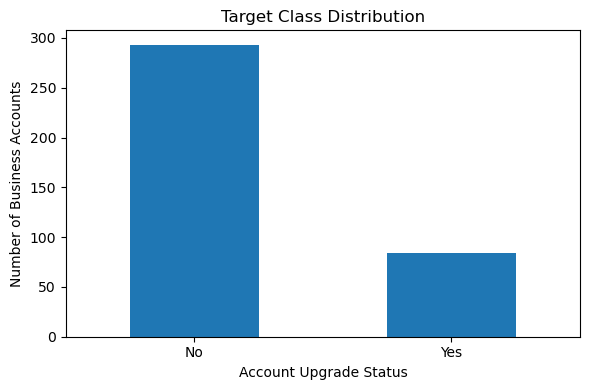

In [16]:
# Create the outputs folder if it does not already exist
from pathlib import Path
Path("outputs").mkdir(exist_ok=True)

# Clean column names by removing extra spaces
df.columns = df.columns.str.strip()

# Calculate the target class distribution
target_distribution = df["Upgraded_Account"].value_counts()

# Display the target distribution
print("Target Class Distribution:")
print(target_distribution)

# Create a bar chart for target class distribution
plt.figure(figsize=(6, 4))

# Plot the target class distribution
target_distribution.plot(kind="bar")

# Add chart title and labels
plt.title("Target Class Distribution")
plt.xlabel("Account Upgrade Status")
plt.ylabel("Number of Business Accounts")

# Rotate x-axis labels
plt.xticks(rotation=0)

# Adjust the layout
plt.tight_layout()

# Save the chart
plt.savefig("outputs/target_class_distribution.png", dpi=300, bbox_inches="tight")

# Display the chart
plt.show()

## Step 6: Checking Numerical and Categorical Variables

In this step, the dataset is separated into numerical and categorical feature columns. This is important because numerical and categorical variables require different preprocessing methods before model training.

Numerical variables are already stored as numbers and can usually be scaled after missing values are handled. Categorical variables contain text-based values, such as industry, current plan, sales contact status, or training attendance. These categorical variables must later be converted into numerical format before they can be used by the Logistic Regression model.

The `Account_ID` column is excluded because it is only an identifier. The target column, `Upgraded_Account`, is also excluded because it is the value that the model is trying to predict.


In [56]:
# Create the outputs folder if it does not already exist
from pathlib import Path
Path("outputs").mkdir(exist_ok=True)

# Clean column names by removing extra spaces
df.columns = df.columns.str.strip()

# Define the target column and ID column
target_column = "Upgraded_Account"
id_column = "Account_ID"

# Create a feature-only dataset by removing the target column and ID column
feature_data = df.drop(columns=[target_column, id_column])

# Select numerical feature columns
numerical_features_initial = feature_data.select_dtypes(include=["number"]).columns.tolist()

# Select categorical feature columns
categorical_features_initial = feature_data.select_dtypes(include=["object", "string","category", "bool"]).columns.tolist()

# Print numerical feature columns
print("Numerical Feature Columns")
print("-" * 50)
print(numerical_features_initial)

# Print categorical feature columns
print("\nCategorical Feature Columns")
print("-" * 50)
print(categorical_features_initial)

Numerical Feature Columns
--------------------------------------------------
['Annual_Revenue', 'Monthly_Transactions', 'Account_Age_Months', 'Support_Tickets', 'Product_Usage_Score', 'Monthly_Fee']

Categorical Feature Columns
--------------------------------------------------
['Company_Size', 'Industry', 'Current_Plan', 'Sales_Contacted', 'Training_Attended']


In [18]:
# Create a table showing the number of numerical and categorical features
feature_type_summary = pd.DataFrame({
    "Feature Type": ["Numerical", "Categorical"],
    "Number of Features": [len(numerical_features_initial), len(categorical_features_initial)]
})

# Display the feature type summary table
display(feature_type_summary)

,Feature Type,Number of Features
0,Numerical,6
1,Categorical,5


In [19]:
# Count unique values for each categorical feature
categorical_unique_counts = feature_data[categorical_features_initial].nunique()

# Print a title
print("Number of Unique Values in Each Categorical Feature")
print("-" * 50)

# Display the number of unique values
display(categorical_unique_counts)

Number of Unique Values in Each Categorical Feature
--------------------------------------------------


Company_Size         4
Industry             6
Current_Plan         4
Sales_Contacted      2
Training_Attended    2
dtype: int64

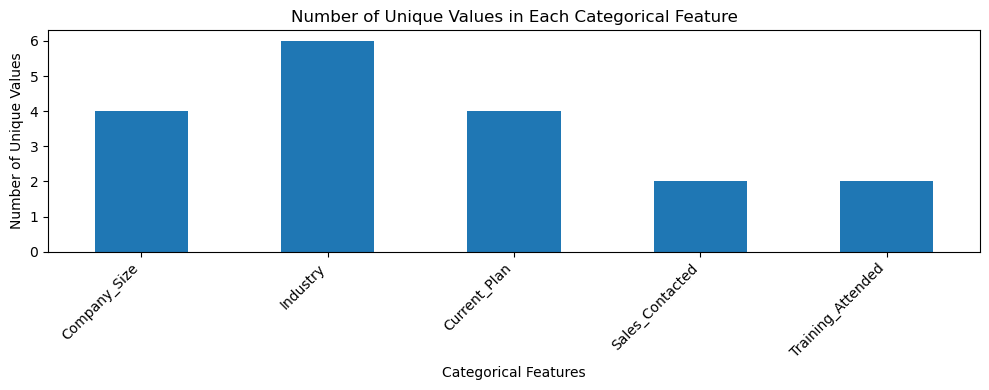

In [20]:
# Create a figure for the categorical unique values chart
plt.figure(figsize=(10, 4))

# Create a bar chart for the number of unique values in each categorical feature
categorical_unique_counts.plot(kind="bar")

# Add a title to the chart
plt.title("Number of Unique Values in Each Categorical Feature")

# Add a label to the x-axis
plt.xlabel("Categorical Features")

# Add a label to the y-axis
plt.ylabel("Number of Unique Values")

# Rotate x-axis labels to make them easier to read
plt.xticks(rotation=45, ha="right")

# Adjust the layout so labels do not overlap
plt.tight_layout()

# Save the chart in the outputs folder
plt.savefig("outputs/categorical_unique_values.png", dpi=300, bbox_inches="tight")

# Display the chart
plt.show()

### Short Interpretation

The dataset contains both numerical and categorical feature columns. This confirms that different preprocessing steps will be needed before model training.

The numerical features can be handled with missing-value imputation and scaling. The categorical features will need to be converted into numerical format using one-hot encoding because Logistic Regression cannot directly use text-based categories.

The `Account_ID` column has been excluded because it is only an identifier, and the target column, `Upgraded_Account`, has also been excluded because it is the prediction outcome.

At this stage, the feature types have been identified only for inspection. The final `X` and `y` variables will be created after the data cleaning steps are completed.

## Step 7: Data Cleaning

Before training a machine learning model, the dataset must be cleaned to make sure it is suitable for analysis and model development.

In this step, a copy of the original dataset is created before making any changes. This is a good practice because it keeps the original dataset unchanged and allows the cleaned version to be used for later steps in the machine learning pipeline.

The main cleaning task in this step is to check for duplicate rows and remove them if they exist. Duplicate rows can affect model training because repeated records may give extra weight to the same information. This can lead the model to learn from repeated observations rather than from a balanced representation of the dataset.

At this stage, missing values are not filled yet. Missing values will be handled in the next step using appropriate methods for numerical and categorical variables before creating the final feature matrix `X` and target variable `y`.

In [21]:
# Create a copy of the original dataset
df_clean = df.copy()

# Print a message to confirm that the copy was created
print("A copy of the dataset has been created.")

# Show the shape of the original dataset
print("Original dataset shape:", df.shape)

# Show the shape of the copied dataset
print("Copied dataset shape:", df_clean.shape)

A copy of the dataset has been created.
Original dataset shape: (377, 13)
Copied dataset shape: (377, 13)


In [22]:
# Count the number of duplicate rows before cleaning
duplicates_before = df_clean.duplicated().sum()

# Print the number of duplicate rows before cleaning
print("Number of duplicate rows before cleaning:", duplicates_before)

Number of duplicate rows before cleaning: 7


In [23]:
# Remove duplicate rows from the dataset
df_clean = df_clean.drop_duplicates()

# Print a message to confirm that duplicate rows were removed
print("Duplicate rows have been removed.")

Duplicate rows have been removed.


In [24]:
# Show the shape of the dataset after removing duplicate rows
print("Dataset shape after removing duplicates:", df_clean.shape)

# Count the number of duplicate rows after cleaning
duplicates_after = df_clean.duplicated().sum()

# Print the number of duplicate rows after cleaning
print("Number of duplicate rows after cleaning:", duplicates_after)

Dataset shape after removing duplicates: (370, 13)
Number of duplicate rows after cleaning: 0


In [25]:
# Display the first five rows of the cleaned dataset
display(df_clean.head())

,Account_ID,Company_Size,Industry,Annual_Revenue,Monthly_Transactions,Current_Plan,Account_Age_Months,Support_Tickets,Sales_Contacted,Product_Usage_Score,Monthly_Fee,Training_Attended,Upgraded_Account
0,1,Small,Healthcare,4765975.0,368,Business,26,5,No,55.0,2832,Yes,No
1,2,Small,Manufacturing,5683548.0,257,Basic,75,4,No,5.0,1215,Yes,No
2,3,Enterprise,Manufacturing,1722517.0,424,Premium,99,0,No,64.0,753,No,No
3,4,Enterprise,Education,3481277.0,190,Standard,33,0,Yes,86.0,1973,No,Yes
4,5,Small,Finance,1023375.0,262,Basic,52,3,No,88.0,3676,Yes,No


## Step 8: Handling Missing Values

In this step, missing values are handled in the cleaned dataset.

Missing values can cause errors during model training because most machine learning algorithms cannot work directly with empty cells. Therefore, missing values must be treated before creating the final feature matrix and training the model.

For numerical feature columns, missing values are filled using the median value of each column. The median is used because it is less affected by extreme values than the mean.

For categorical feature columns, missing values are filled using the most frequent value, also called the mode. This allows the dataset to keep those records instead of removing them unnecessarily.

The target variable, `Upgraded_Account`, should not be filled using the median or mode because it represents the actual outcome that the model is trying to predict. If the target variable has missing values, those rows should be removed because the model needs a known answer to learn from the data.

This step helps prepare a more complete and reliable dataset for the next stages of the machine learning pipeline.

In [26]:
# Print a title for this output
print("Missing Values Before Handling")

# Print a separator line to make the output clear
print("-" * 50)

# Count missing values in each column before handling them
missing_values_before = df_clean.isnull().sum()

# Display missing values before handling
display(missing_values_before)

Missing Values Before Handling
--------------------------------------------------


Account_ID              0
Company_Size            7
Industry                7
Annual_Revenue          7
Monthly_Transactions    0
Current_Plan            7
Account_Age_Months      0
Support_Tickets         0
Sales_Contacted         7
Product_Usage_Score     7
Monthly_Fee             0
Training_Attended       0
Upgraded_Account        0
dtype: int64

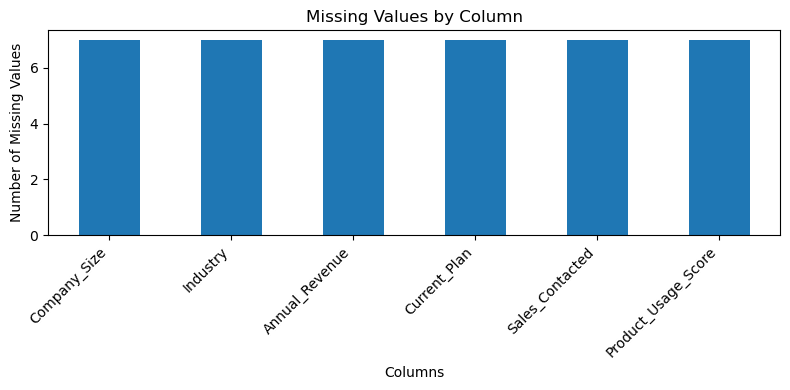

In [27]:
# Import matplotlib for creating charts
import matplotlib.pyplot as plt

# Select only columns that have missing values
missing_columns = missing_values_before[missing_values_before > 0]

# Check whether there are missing values before creating the chart
if len(missing_columns) > 0:
    
    # Create a figure for the missing values chart
    plt.figure(figsize=(8, 4))
    
    # Create a bar chart for columns with missing values
    missing_columns.plot(kind="bar")
    
    # Add a title to the chart
    plt.title("Missing Values by Column")
    
    # Add a label to the x-axis
    plt.xlabel("Columns")
    
    # Add a label to the y-axis
    plt.ylabel("Number of Missing Values")
    
    # Rotate x-axis labels to make them easier to read
    plt.xticks(rotation=45, ha="right")
    
    # Adjust the layout so labels do not overlap
    plt.tight_layout()
    
    # Display the chart
    plt.show()

else:
    print("There are no missing values to display in a chart.")

In [28]:
# Check whether the target variable has missing values
missing_target_values = df_clean[target_column].isnull().sum()

print("Missing values in target variable:", missing_target_values)

Missing values in target variable: 0


In [29]:
# Remove rows where the target variable is missing, if any
# The model needs a known target value to learn from the data
df_clean = df_clean.dropna(subset=[target_column])

# Print the dataset shape after checking the target variable
print("Dataset shape after checking target missing values:", df_clean.shape)

Dataset shape after checking target missing values: (370, 13)


In [30]:
# Define columns that should not be filled as normal features
columns_to_exclude = ["Account_ID", target_column]

# Create a feature-only dataset for identifying numerical and categorical feature columns
feature_data_for_missing = df_clean.drop(columns=columns_to_exclude, errors="ignore")

# Select numerical feature columns from the cleaned dataset
numerical_columns = feature_data_for_missing.select_dtypes(include=["int64", "float64"]).columns.tolist()

# Select categorical feature columns from the cleaned dataset
categorical_columns = feature_data_for_missing.select_dtypes(include=["object", "string", "category"]).columns.tolist()

# Print numerical columns
print("Numerical feature columns:")
print(numerical_columns)

print("-" * 50)

# Print categorical columns
print("Categorical feature columns:")
print(categorical_columns)

Numerical feature columns:
['Annual_Revenue', 'Monthly_Transactions', 'Account_Age_Months', 'Support_Tickets', 'Product_Usage_Score', 'Monthly_Fee']
--------------------------------------------------
Categorical feature columns:
['Company_Size', 'Industry', 'Current_Plan', 'Sales_Contacted', 'Training_Attended']


In [31]:
# Loop through each numerical feature column
for column in numerical_columns:
    
    # Calculate the median value of the current numerical column
    median_value = df_clean[column].median()
    
    # Fill missing values in the current column with the median value
    df_clean[column] = df_clean[column].fillna(median_value)

# Print a message after handling numerical missing values
print("Missing values in numerical feature columns have been filled with the median.")

Missing values in numerical feature columns have been filled with the median.


In [32]:
# Loop through each categorical feature column
for column in categorical_columns:
    
    # Calculate the most frequent value of the current categorical column
    mode_value = df_clean[column].mode()[0]
    
    # Fill missing values in the current column with the most frequent value
    df_clean[column] = df_clean[column].fillna(mode_value)

# Print a message after handling categorical missing values
print("Missing values in categorical feature columns have been filled with the mode.")

Missing values in categorical feature columns have been filled with the mode.


In [33]:
# Print a title for this output
print("Missing Values After Handling")

# Print a separator line to make the output clear
print("-" * 50)

# Count missing values after handling them
missing_values_after = df_clean.isnull().sum()

# Display missing values after handling
display(missing_values_after)

Missing Values After Handling
--------------------------------------------------


Account_ID              0
Company_Size            0
Industry                0
Annual_Revenue          0
Monthly_Transactions    0
Current_Plan            0
Account_Age_Months      0
Support_Tickets         0
Sales_Contacted         0
Product_Usage_Score     0
Monthly_Fee             0
Training_Attended       0
Upgraded_Account        0
dtype: int64

In [34]:
# Print the shape of the cleaned dataset after handling missing values
print("Dataset shape after handling missing values:", df_clean.shape)

# Display the first five rows of the cleaned dataset
display(df_clean.head())

Dataset shape after handling missing values: (370, 13)


,Account_ID,Company_Size,Industry,Annual_Revenue,Monthly_Transactions,Current_Plan,Account_Age_Months,Support_Tickets,Sales_Contacted,Product_Usage_Score,Monthly_Fee,Training_Attended,Upgraded_Account
0,1,Small,Healthcare,4765975.0,368,Business,26,5,No,55.0,2832,Yes,No
1,2,Small,Manufacturing,5683548.0,257,Basic,75,4,No,5.0,1215,Yes,No
2,3,Enterprise,Manufacturing,1722517.0,424,Premium,99,0,No,64.0,753,No,No
3,4,Enterprise,Education,3481277.0,190,Standard,33,0,Yes,86.0,1973,No,Yes
4,5,Small,Finance,1023375.0,262,Basic,52,3,No,88.0,3676,Yes,No


### Short Interpretation

After handling missing values, the cleaned dataset no longer contains empty values in the selected feature columns.

Numerical missing values were filled using the median, while categorical missing values were filled using the most frequent value. The target variable, `Upgraded_Account`, was checked separately because it represents the actual prediction outcome.

The dataset is now more complete and ready for creating the final feature matrix `X` and target variable `y`.

## Step 9: Defining X and y

In this step, the cleaned dataset is separated into feature variables and the target variable.

The target variable is `Upgraded_Account`. This is the variable that the Logistic Regression model will try to predict.

The feature variables are the input columns that the model will use to make predictions. These columns describe business account information, account activity, revenue details, product usage, sales contact status, support history, and training-related information.

The `Account_ID` column is removed because it is only an identification number. It does not provide meaningful information for predicting whether a business account will upgrade.

Therefore:

* `X` contains the feature variables used to make predictions.
* `y` contains the target variable, `Upgraded_Account`.

After this step, `X` will contain the input data, and `y` will contain the outcome that the model needs to learn from.


In [35]:
# Define the target variable
target = "Upgraded_Account"

# Define X by removing the target column and Account_ID from the cleaned dataset
X = df_clean.drop(columns=[target, "Account_ID"])

# Define y as the target variable from the cleaned dataset
y = df_clean[target]

# Display the shape of X and y
print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

# Display selected feature columns
print("\nFeature columns:")
print(X.columns.tolist())

# Display target variable name
print("\nTarget variable:")
print(target)

Shape of X: (370, 11)
Shape of y: (370,)

Feature columns:
['Company_Size', 'Industry', 'Annual_Revenue', 'Monthly_Transactions', 'Current_Plan', 'Account_Age_Months', 'Support_Tickets', 'Sales_Contacted', 'Product_Usage_Score', 'Monthly_Fee', 'Training_Attended']

Target variable:
Upgraded_Account


In [36]:
# Show the first five rows of X
display(X.head())

,Company_Size,Industry,Annual_Revenue,Monthly_Transactions,Current_Plan,Account_Age_Months,Support_Tickets,Sales_Contacted,Product_Usage_Score,Monthly_Fee,Training_Attended
0,Small,Healthcare,4765975.0,368,Business,26,5,No,55.0,2832,Yes
1,Small,Manufacturing,5683548.0,257,Basic,75,4,No,5.0,1215,Yes
2,Enterprise,Manufacturing,1722517.0,424,Premium,99,0,No,64.0,753,No
3,Enterprise,Education,3481277.0,190,Standard,33,0,Yes,86.0,1973,No
4,Small,Finance,1023375.0,262,Basic,52,3,No,88.0,3676,Yes


In [37]:
# Show the first five values of y
display(y.head())

0     No
1     No
2     No
3    Yes
4     No
Name: Upgraded_Account, dtype: str

In [38]:
# Print target class distribution after cleaning
print("Target Class Distribution After Cleaning")
print("-" * 50)

target_counts_clean = y.value_counts()
display(target_counts_clean)

Target Class Distribution After Cleaning
--------------------------------------------------


Upgraded_Account
No     288
Yes     82
Name: count, dtype: int64

Target Variable Distribution After Cleaning:
Upgraded_Account
No     288
Yes     82
Name: count, dtype: int64


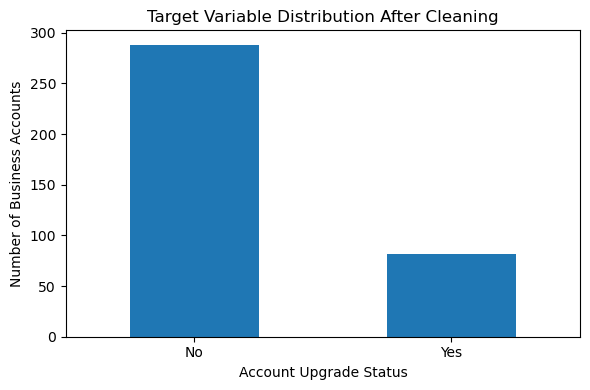

In [39]:
# Make sure matplotlib displays charts inside Jupyter
%matplotlib inline

# Create the outputs folder if it does not already exist
from pathlib import Path
Path("outputs").mkdir(exist_ok=True)

# Calculate target distribution after cleaning
target_counts_clean = df_clean["Upgraded_Account"].value_counts()

# Display the cleaned target distribution
print("Target Variable Distribution After Cleaning:")
print(target_counts_clean)

# Create a figure for the target distribution chart after cleaning
plt.figure(figsize=(6, 4))

# Create a bar chart for the cleaned target variable distribution
target_counts_clean.plot(kind="bar")

# Add a title to the chart
plt.title("Target Variable Distribution After Cleaning")

# Add a label to the x-axis
plt.xlabel("Account Upgrade Status")

# Add a label to the y-axis
plt.ylabel("Number of Business Accounts")

# Rotate x-axis labels to make them easier to read
plt.xticks(rotation=0)

# Adjust layout to avoid overlap
plt.tight_layout()

# Save the chart
plt.savefig("outputs/target_distribution_after_cleaning.png", dpi=300, bbox_inches="tight")

# Display the chart
plt.show()

### Short Interpretation

The cleaned dataset has now been separated into X and y. The feature matrix X contains the input variables, while y contains the target variable, Upgraded_Account.

The Account_ID column was excluded because it is only an identifier. The target variable was also excluded from X to avoid using the answer column as an input feature.

The target distribution after cleaning shows the number of upgraded and non-upgraded business accounts. This helps us understand the class balance before training the Logistic Regression model.

## Step 10: Train-Test Split

In this step, the dataset is split into training and testing sets.

The training set is used to train the Logistic Regression model, while the testing set is kept separate and used to evaluate how well the model performs on new, unseen data. This helps us check whether the model can generalize to business accounts that it has not seen during training.

For this assignment, 80% of the data is used for training and 20% is used for testing. The parameter `random_state=42` is used to make the split reproducible, meaning the same split can be created again when the notebook is rerun.

The parameter `stratify=y` is also used to keep the distribution of the `Yes` and `No` target classes similar in both the training and testing sets. This is important because both upgraded and non-upgraded accounts should be represented fairly during model training and evaluation.


In [40]:
# Import train_test_split to split the dataset
from sklearn.model_selection import train_test_split

# Split X and y into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Create a table showing the shape of each dataset
split_summary = pd.DataFrame({
    "Dataset": ["X_train", "X_test", "y_train", "y_test"],
    "Shape": [X_train.shape, X_test.shape, y_train.shape, y_test.shape]
})

# Print a message to confirm that the data has been split
print("Data has been split into training and testing sets.\n")

# Display split summary
display(split_summary)

Data has been split into training and testing sets.



,Dataset,Shape
0,X_train,"(296, 11)"
1,X_test,"(74, 11)"
2,y_train,"(296,)"
3,y_test,"(74,)"


In [41]:
# Create a comparison table for target distribution in training and testing sets
split_target_distribution = pd.DataFrame({
    "Training Set": y_train.value_counts().sort_index(),
    "Testing Set": y_test.value_counts().sort_index()
})
print("Comparison table for target distribution in training and testing sets")
print("-" * 70)

# Display the comparison table
display(split_target_distribution)

Comparison table for target distribution in training and testing sets
----------------------------------------------------------------------


,Training Set,Testing Set
Upgraded_Account,,
No,230,58
Yes,66,16


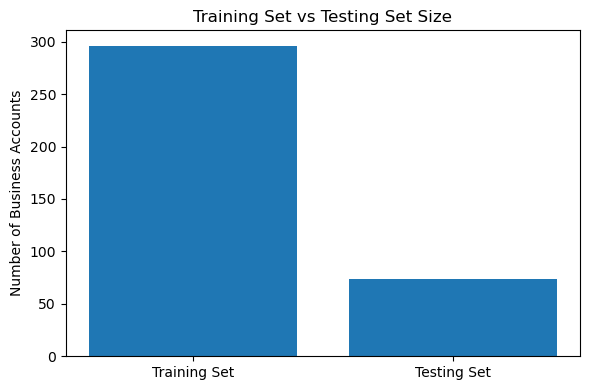

In [42]:
# Create labels for the chart
split_labels = ["Training Set", "Testing Set"]

# Create values for the chart
split_sizes = [len(X_train), len(X_test)]

# Create a figure for the chart
plt.figure(figsize=(6, 4))

# Create a bar chart for train and test size
plt.bar(split_labels, split_sizes)

# Add a title to the chart
plt.title("Training Set vs Testing Set Size")

# Add a label to the y-axis
plt.ylabel("Number of Business Accounts")

# Adjust the layout
plt.tight_layout()

# Save the chart in the outputs folder
plt.savefig("outputs/train_test_split_size.png", dpi=300, bbox_inches="tight")

# Display the chart
plt.show()

## Step 11: Preprocessing

Preprocessing prepares the feature data for the Logistic Regression model.

In this step, numerical and categorical variables are handled differently. Numerical features are scaled using `StandardScaler`, while categorical features are converted into numerical format using `OneHotEncoder`.

Scaling is important for Logistic Regression because numerical variables may have different ranges. For example, annual revenue may have much larger values than support tickets or product usage scores. Standardization helps place numerical variables on a comparable scale.

Categorical variables must be encoded because machine learning models cannot directly use text-based categories such as industry, current plan, sales contact status, or training attendance.

The preprocessing steps are organized using a `ColumnTransformer`. This allows the correct transformation to be applied to each type of feature and helps keep the machine learning workflow clear and consistent.

In [57]:
# Identify numerical feature columns from final X
numerical_features = X.select_dtypes(include=["number"]).columns.tolist()

# Identify categorical feature columns from final X
categorical_features = X.select_dtypes(include=["object", "category", "string", "category", "bool"]).columns.tolist()

print("Numerical features:")
print(numerical_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['Annual_Revenue', 'Monthly_Transactions', 'Account_Age_Months', 'Support_Tickets', 'Product_Usage_Score', 'Monthly_Fee']

Categorical features:
['Company_Size', 'Industry', 'Current_Plan', 'Sales_Contacted', 'Training_Attended']


In [44]:
# Import preprocessing tools
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Create preprocessing steps for numerical columns
numerical_transformer = Pipeline(steps=[
    ("scaler", StandardScaler())
])

# Create preprocessing steps for categorical columns
categorical_transformer = Pipeline(steps=[
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

# Combine numerical and categorical preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numerical_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

print("Preprocessing pipeline created successfully!")

Preprocessing pipeline created successfully!


### Short Interpretation

The preprocessing pipeline has been created successfully. It separates numerical and categorical features and applies the correct transformation to each group.

This prepares the feature data for the Logistic Regression model while keeping the workflow organized and consistent.

## Step 12: Logistic Regression Baseline Model

In this step, a Logistic Regression model is trained as the baseline classification model.

Logistic Regression is suitable for this assignment because the target variable, `Upgraded_Account`, has two possible outcomes: **Yes** and **No**. This makes the problem a binary classification task.

The model learns patterns from the training data and uses those patterns to predict whether a business account is likely to upgrade or not. Logistic Regression is a useful baseline model because it is simple, commonly used, and easy to interpret compared with more advanced machine learning models.

The purpose of using a baseline model is to establish an initial performance level. In future work, more advanced models such as Decision Tree, Random Forest, Support Vector Machine, or Gradient Boosting could be compared against this baseline.

In [45]:
# Import Logistic Regression
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

# Create the Logistic Regression pipeline
logistic_regression_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, random_state=42))
])

# Train the model using the training data
logistic_regression_model.fit(X_train, y_train)

# Print confirmation
print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


## Step 13: Model Prediction

After training the Logistic Regression model, the testing data is used to make predictions.

The testing data was not used during model training. Therefore, predictions on the testing set help show how the model performs on unseen business account records.

In this step, the model predicts whether each business account in the testing set is likely to upgrade or not. The predicted values are then compared with the actual values in the next step to evaluate model performance.

In [46]:
# Make predictions using the trained Logistic Regression model
y_pred = logistic_regression_model.predict(X_test)

# Create a DataFrame to compare actual and predicted values
prediction_results = pd.DataFrame({
    "Actual": y_test.reset_index(drop=True),
    "Predicted": y_pred
})

# Display the first 10 actual and predicted values
prediction_results.head(10)

,Actual,Predicted
0,No,No
1,No,No
2,Yes,No
3,No,No
4,No,No
5,No,No
6,Yes,Yes
7,No,No
8,Yes,Yes
9,No,No


## Step 14: Model Evaluation

After making predictions, the model is evaluated by comparing the predicted values with the actual values from the testing dataset.

The main evaluation metrics include accuracy, precision, recall, F1-score, and the confusion matrix.

Accuracy shows the overall percentage of correct predictions. Precision shows how many accounts predicted as upgraded were actually upgraded. Recall shows how many actual upgraded accounts were correctly identified by the model. F1-score provides a balance between precision and recall.

The confusion matrix gives a more detailed view of correct and incorrect predictions, including true positives, true negatives, false positives, and false negatives.

In [47]:
accuracy = accuracy_score(y_test, y_pred)
precision_yes = precision_score(y_test, y_pred, pos_label="Yes", zero_division=0)
recall_yes = recall_score(y_test, y_pred, pos_label="Yes", zero_division=0)
f1_yes = f1_score(y_test, y_pred, pos_label="Yes", zero_division=0)

metrics_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision for Yes", "Recall for Yes", "F1-score for Yes"],
    "Score": [accuracy, precision_yes, recall_yes, f1_yes]
})

metrics_df

,Metric,Score
0,Accuracy,0.756757
1,Precision for Yes,0.416667
2,Recall for Yes,0.312500
3,F1-score for Yes,0.357143


In [48]:
print("Classification Report:")
print(classification_report(y_test, y_pred, zero_division=0))

Classification Report:
              precision    recall  f1-score   support

          No       0.82      0.88      0.85        58
         Yes       0.42      0.31      0.36        16

    accuracy                           0.76        74
   macro avg       0.62      0.60      0.60        74
weighted avg       0.73      0.76      0.74        74



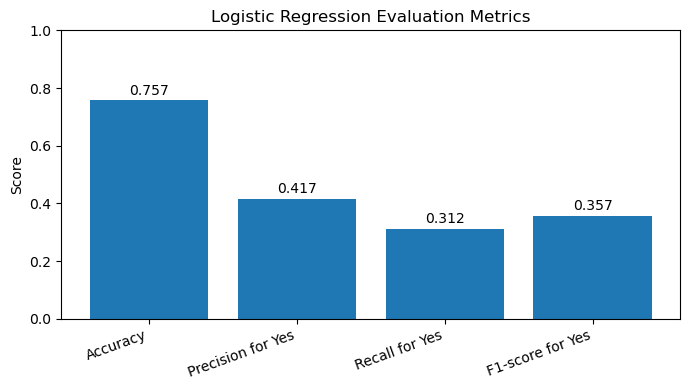

In [49]:
plt.figure(figsize=(7, 4))
plt.bar(metrics_df["Metric"], metrics_df["Score"])
plt.ylim(0, 1)
plt.title("Logistic Regression Evaluation Metrics")
plt.ylabel("Score")
plt.xticks(rotation=20, ha="right")

for index, value in enumerate(metrics_df["Score"]):
    plt.text(index, value + 0.02, f"{value:.3f}", ha="center")

plt.tight_layout()
plt.show()

In [50]:
# Create confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=["No", "Yes"])

# Convert confusion matrix to a DataFrame for clearer display
cm_df = pd.DataFrame(
    cm,
    index=["Actual No", "Actual Yes"],
    columns=["Predicted No", "Predicted Yes"]
)

# Display confusion matrix
print("Confusion Matrix:")
display(cm_df)

Confusion Matrix:


,Predicted No,Predicted Yes
Actual No,51,7
Actual Yes,11,5


Confusion Matrix:
[[51  7]
 [11  5]]


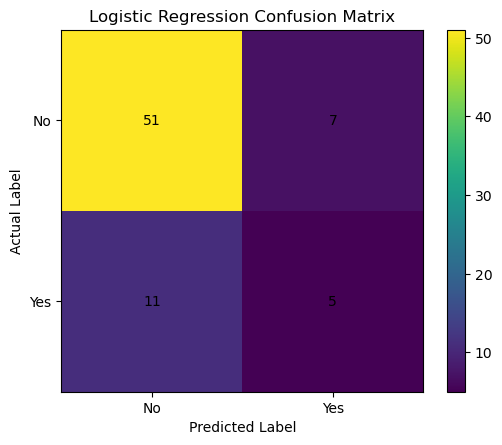

In [51]:
# Import confusion matrix
from sklearn.metrics import confusion_matrix

# Define class labels
labels = ["No", "Yes"]

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=labels)

# Display confusion matrix values
print("Confusion Matrix:")
print(cm)

# Create a figure for the confusion matrix
plt.figure(figsize=(5.5, 4.5))

# Display confusion matrix as an image
plt.imshow(cm)

# Add chart title and labels
plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

# Add class labels to x-axis and y-axis
plt.xticks(ticks=[0, 1], labels=labels)
plt.yticks(ticks=[0, 1], labels=labels)

# Add numbers inside each cell
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, str(cm[i, j]), ha="center", va="center")

# Add color bar
plt.colorbar()

# Adjust layout
plt.tight_layout()

# Save the chart
plt.savefig("outputs/logistic_regression_confusion_matrix.png", dpi=300, bbox_inches="tight")

# Display the chart
plt.show()

### Short Interpretation

The confusion matrix shows how many business accounts were correctly and incorrectly classified by the Logistic Regression model.

The diagonal values show correct predictions, while the off-diagonal values show incorrect predictions. This helps us understand whether the model performs better at predicting upgraded accounts or non-upgraded accounts.

In [52]:
train_accuracy = logistic_regression_model.score(X_train, y_train)
test_accuracy = logistic_regression_model.score(X_test, y_test)
accuracy_gap = train_accuracy - test_accuracy

accuracy_comparison = pd.DataFrame({
    "Dataset": ["Training Set", "Testing Set", "Difference"],
    "Accuracy": [train_accuracy, test_accuracy, accuracy_gap]
})

accuracy_comparison

,Dataset,Accuracy
0,Training Set,0.895270
1,Testing Set,0.756757
2,Difference,0.138514


## Step 15: Result Interpretation and Business Meaning

The Logistic Regression model was used as a baseline model to predict whether a business account would upgrade or not.

The accuracy score shows the overall percentage of correct predictions made by the model on the testing data. The confusion matrix provides a more detailed view by showing how many accounts were correctly and incorrectly classified as upgraded or not upgraded.

The classification report gives precision, recall, and F1-score for each class. These metrics are useful because accuracy alone may not fully explain model performance, especially if the dataset has more `No` values than `Yes` values.

From a business perspective, the model can help the company identify business accounts that may be more likely to upgrade. Accounts predicted as likely to upgrade could be prioritized for sales follow-up, customer success support, product demonstrations, training support, or targeted upgrade campaigns.

However, the model should be used as a decision-support tool rather than a final decision-making system. Business staff should combine the model output with customer knowledge, account history, and professional judgment before taking action.

In [53]:
# Print a simple automatic result summary
print("Model Result Summary")
print("-" * 50)
print("The model is trying to predict whether a business account will upgrade or not.")
print("The target variable is Upgraded_Account.")
print("The baseline model used is Logistic Regression.")
print("Accuracy percentage:", round(accuracy * 100, 2), "%")

Model Result Summary
--------------------------------------------------
The model is trying to predict whether a business account will upgrade or not.
The target variable is Upgraded_Account.
The baseline model used is Logistic Regression.
Accuracy percentage: 75.68 %


## Step 16: Final Explanation of the Model

The model is trying to predict whether a business account will upgrade its account or not.

The dataset used in this assignment is `business_account_upgrade_prediction_dataset.csv`. The dataset contains business account information such as company size, industry, annual revenue, monthly transactions, current plan, account age, support tickets, sales contact status, product usage score, monthly fee, training attendance, and whether the account upgraded.

The target variable selected for prediction is `Upgraded_Account`.

The feature variables selected for model training are:

* `Company_Size`
* `Industry`
* `Annual_Revenue`
* `Monthly_Transactions`
* `Current_Plan`
* `Account_Age_Months`
* `Support_Tickets`
* `Sales_Contacted`
* `Product_Usage_Score`
* `Monthly_Fee`
* `Training_Attended`

The `Account_ID` column was removed because it is only an identifier and does not provide useful predictive information.

The baseline Logistic Regression model was trained using the training dataset and evaluated using the testing dataset. The model achieved an accuracy of approximately **75.68%** on the test data. This means the model correctly predicted about 76% of the test accounts.

The confusion matrix and classification report show that the model performs better in predicting accounts that did not upgrade than accounts that upgraded. This may be partly because the dataset contains more `No` values than `Yes` values.

## Step 17: Limitation of the Model

One limitation of this model is that the dataset is imbalanced. There are more accounts that did not upgrade than accounts that upgraded. Because of this, the model may perform better at predicting the majority class, which is `No`, and may be weaker at identifying accounts that actually upgraded.

Another limitation is that the model is based only on the variables available in the dataset. Real business account upgrade decisions may depend on other factors that are not included, such as customer budget, competitor offers, contract negotiations, service satisfaction, management decisions, or future business plans.

Logistic Regression is also a simple baseline model. While it is useful for starting the machine learning pipeline, it may not capture more complex patterns in the data. Future work could compare Logistic Regression with other classification models such as Decision Tree, Random Forest, Support Vector Machine, or Gradient Boosting.

## Step 18: Responsible AI Reflection

This model should be used as a decision-support tool, not as the only basis for business decisions.

The model predicts whether a business account is likely to upgrade, but it may still make incorrect predictions. For example, some accounts predicted as unlikely to upgrade may actually upgrade later, and some accounts predicted as likely to upgrade may not upgrade.

The company should not use the model to unfairly ignore, exclude, or deprioritize customers. Human judgment is still important, especially when making sales, support, pricing, or customer relationship decisions.

One responsible AI concern is class imbalance. Since there are more accounts that did not upgrade than accounts that upgraded, the model may perform better for the majority class and may be weaker at identifying upgrade customers.

Another concern is data quality. If the dataset contains missing values, outdated information, or limited business variables, the model’s predictions may not fully reflect real customer behaviour.

Therefore, before using this model in a real business setting, the company should test it further, monitor its performance, check for bias, and make sure predictions are used fairly and responsibly.

## Step 19: Final Conclusion

This notebook completed an end-to-end machine learning pipeline for predicting business account upgrades using a Logistic Regression baseline model.

The workflow included understanding the business problem, loading and inspecting the dataset, identifying the target variable and input features, cleaning the data, handling missing values, defining `X` and `y`, splitting the dataset, preprocessing numerical and categorical variables, training the model, making predictions, and evaluating the results.

The model provides a useful starting point for predicting whether a business account may upgrade. It can support business decision-making by helping the company identify accounts that may be suitable for sales follow-up, customer success support, training, engagement, or upgrade-related actions.

Overall, this assignment demonstrates how a structured machine learning pipeline can transform business data into a practical prediction model that supports data-driven decision-making.